# Figure 5 — angle between within- and across-hemisphere co-fluctuation patterns
### Bilateral vs. unilateral experts

This notebook reproduces **Figure 5c** of McDonnell, Umakantha, Williamson, Smith & Yu
(*Interactions across hemispheres in prefrontal cortex reflect global cognitive processing*,
Nat Commun 2026), applied to our bilateral-M1 pCCA-FA fits and **split by training group**.

**The question (Scott, Comments 2–3).** For each hemisphere we have two co-fluctuation
patterns from the fitted pCCA-FA model:

- the **top across-area pattern** — the direction along which this hemisphere co-fluctuates
  with the *other* hemisphere (leading singular vector of the across-area loadings `W`);
- the **top within-area pattern** — the direction along which this hemisphere co-fluctuates
  with *itself* (leading singular vector of the within-area loadings `L`).

`theta` is the principal angle between them:
`theta ≈ 0°` → same neurons drive both (aligned mechanisms);
`theta ≈ 90°` → distinct directions (separate mechanisms).

**Hypothesis:** bilateral experts have a **smaller theta** (patterns more aligned) than
unilateral experts.

The angle math is a faithful port of `dual_pfc_funcs.get_top_angle` / `prinangle`
(`across_mode='cov'`), so numbers are directly comparable to the paper. All inputs come from
the already-fitted `results/*_w0.0-1.0.joblib` payloads — nothing is refit here.

Unit of analysis is a **hemisphere** (each session contributes LH + RH), matching the
paper's "# of brain areas".


In [1]:
import sys, os
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

sys.path.insert(0, '.')            # so `tools` is importable when run from repo root
from tools.fig5_angles import build_angle_table, session_level_table

# paper style sheet (copied into the repo). Falls back silently if absent.
try:
    plt.style.use('scifigs.mplstyle')
except Exception as e:
    print('scifigs.mplstyle not applied:', e)

# scifigs.mplstyle sets figure.dpi=300. With the %matplotlib widget (ipympl)
# backend the on-screen canvas is figsize*dpi pixels, so 300 makes every figure
# huge. Use a modest DISPLAY dpi here; savefig() below still exports high-res
# because those calls pass their own dpi (and PDFs are vector).
plt.rcParams['figure.dpi'] = 100

# ---- config ----
RESULTS_DIR   = 'results'
WINDOW_SUFFIX = '_w0.0-1.0'        # full-trial fits
FIG_DIR       = 'figures/fig5_angle'
os.makedirs(FIG_DIR, exist_ok=True)
SAVE_FIG      = True

# group colors (distinct from the paper's within/across colors)
GROUP_COLORS = {'bilateral': np.array([0, 144, 255])/255,    # blue
                'unilateral': np.array([255, 128, 0])/255}   # orange


In [2]:
%matplotlib widget

## 1 · Extract the angles (Step 1)
One `theta` per hemisphere, tagged by training group.

In [3]:
angles = build_angle_table(RESULTS_DIR, window_suffix=WINDOW_SUFFIX)
angles


,session,group,hemisphere,area,theta,n_neurons,d,d1,d2,file
0,P1,bilateral,LH,1,65.304152,42,6,1,5,P1_w0.0-1.0.joblib
1,P1,bilateral,RH,2,84.477244,60,6,1,5,P1_w0.0-1.0.joblib
2,P11,bilateral,LH,1,NaN,39,6,0,1,P11_w0.0-1.0.joblib
3,P11,bilateral,RH,2,62.033199,56,6,0,1,P11_w0.0-1.0.joblib
4,P14,bilateral,LH,1,66.980345,64,5,1,3,P14_w0.0-1.0.joblib
5,P14,bilateral,RH,2,78.782753,82,5,1,3,P14_w0.0-1.0.joblib
6,P2,bilateral,LH,1,51.728437,69,6,6,6,P2_w0.0-1.0.joblib
7,P2,bilateral,RH,2,32.403162,64,6,6,6,P2_w0.0-1.0.joblib
8,P3,bilateral,LH,1,80.789766,40,5,1,4,P3_w0.0-1.0.joblib
9,P3,bilateral,RH,2,63.311250,42,5,1,4,P3_w0.0-1.0.joblib


Two hemispheres are dropped because their cross-validated **within-area dimensionality is 0**
(`d1 == 0`) — there is no within-area shared latent, so the within-area pattern (and therefore
the angle) is undefined. `build_angle_table` returns `NaN` for those; we exclude them below.

In [4]:
undefined = angles[angles['theta'].isna()]
print('Undefined (excluded) hemispheres:')
print(undefined[['session', 'group', 'hemisphere', 'd1', 'd2']].to_string(index=False))

valid = angles.dropna(subset=['theta']).copy()
print('\nValid hemispheres: {} of {}'.format(len(valid), len(angles)))

# save the tidy table
csv_path = os.path.join(FIG_DIR, 'fig5_angles_table.csv')
angles.to_csv(csv_path, index=False)
print('Saved ->', csv_path)


Undefined (excluded) hemispheres:
session      group hemisphere  d1  d2
    P11  bilateral         LH   0   1
     U7 unilateral         LH   0   4

Valid hemispheres: 22 of 24
Saved -> figures/fig5_angle/fig5_angles_table.csv


In [5]:
# quick group summary
summary = (valid.groupby('group')['theta']
           .agg(n='count', mean='mean', median='median', std='std')
           .round(2))
summary


,n,mean,median,std
group,,,,
bilateral,15,65.17,65.30,15.10
unilateral,7,77.37,78.94,8.35


## 2 · Figure 5c, split by group (Step 2)
Same style as the paper's panel c: one histogram per group, group-mean marked with ▼.

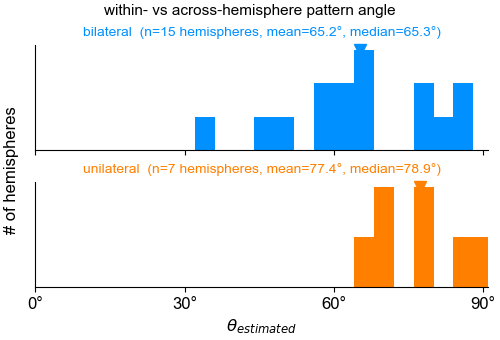

In [6]:
bins = np.arange(0, 95, 4)
groups = ['bilateral', 'unilateral']

fig, axs = plt.subplots(2, 1, sharex=True, constrained_layout=True, figsize=(5, 3.4))
fig.suptitle('within- vs across-hemisphere pattern angle', fontsize=11)
fig.supylabel('# of hemispheres')

for ax, g in zip(axs, groups):
    d = valid.loc[valid.group == g, 'theta'].values
    ax.hist(d, bins=bins, color=GROUP_COLORS[g])
    ymax = ax.get_ylim()[1]
    ax.plot(d.mean(), ymax*0.95, color=GROUP_COLORS[g], marker='v', markersize=8, clip_on=False)
    ax.set_title('{}  (n={} hemispheres, mean={:.1f}°, median={:.1f}°)'
                 .format(g, len(d), d.mean(), np.median(d)),
                 fontsize=10, color=GROUP_COLORS[g])
    ax.set_yticks([])
    ax.set_xlim([0, 91])
    ax.set_xticks(np.arange(0, 91, 30))

axs[-1].set_xlabel(r'$\theta_{estimated}$')
axs[-1].xaxis.set_major_formatter(StrMethodFormatter(u"{x:.0f}°"))

if SAVE_FIG:
    fig.savefig(os.path.join(FIG_DIR, 'fig5c_angle_hist_by_group.pdf'))
    fig.savefig(os.path.join(FIG_DIR, 'fig5c_angle_hist_by_group.png'), dpi=200)
plt.show()


## 3 · Group comparison + statistics (Step 3)
Strip plot of every hemisphere with group mean±SEM, plus formal tests.

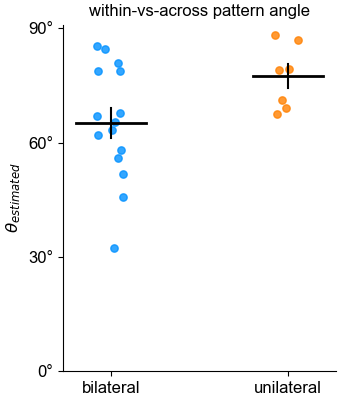

In [7]:
fig, ax = plt.subplots(figsize=(3.4, 4), constrained_layout=True)
rng = np.random.default_rng(0)

for i, g in enumerate(groups):
    d = valid.loc[valid.group == g, 'theta'].values
    x = i + rng.uniform(-0.08, 0.08, size=len(d))
    ax.scatter(x, d, color=GROUP_COLORS[g], s=28, alpha=0.8, zorder=3)
    m, sem = d.mean(), d.std(ddof=1)/np.sqrt(len(d))
    ax.plot([i-0.2, i+0.2], [m, m], color='k', lw=2, zorder=4)
    ax.plot([i, i], [m-sem, m+sem], color='k', lw=1.5, zorder=4)

ax.set_xticks([0, 1])
ax.set_xticklabels(['bilateral', 'unilateral'])
ax.set_ylabel(r'$\theta_{estimated}$')
ax.set_ylim([0, 91])
ax.set_yticks(np.arange(0, 91, 30))
ax.yaxis.set_major_formatter(StrMethodFormatter(u"{x:.0f}°"))
ax.set_title('within-vs-across pattern angle')

if SAVE_FIG:
    fig.savefig(os.path.join(FIG_DIR, 'fig5_angle_group_strip.pdf'))
    fig.savefig(os.path.join(FIG_DIR, 'fig5_angle_group_strip.png'), dpi=200)
plt.show()


In [8]:
# ---- statistics ----
bil = valid.loc[valid.group == 'bilateral', 'theta'].values
uni = valid.loc[valid.group == 'unilateral', 'theta'].values

print('HEMISPHERE-LEVEL (n_bilateral={}, n_unilateral={})'.format(len(bil), len(uni)))
print('  bilateral : mean={:.1f}°  median={:.1f}°'.format(bil.mean(), np.median(bil)))
print('  unilateral: mean={:.1f}°  median={:.1f}°'.format(uni.mean(), np.median(uni)))

# Hypothesis (Scott): bilateral theta < unilateral theta  -> one-sided
u_stat, p_less = stats.mannwhitneyu(bil, uni, alternative='less')
u_stat2, p_two = stats.mannwhitneyu(bil, uni, alternative='two-sided')
t_stat, p_t    = stats.ttest_ind(bil, uni, equal_var=False)
print('  Mann-Whitney U (bilateral < unilateral, one-sided): U={:.1f}, p={:.4f}'.format(u_stat, p_less))
print('  Mann-Whitney U (two-sided)                        : U={:.1f}, p={:.4f}'.format(u_stat2, p_two))
print('  Welch t-test  (two-sided)                         : t={:.2f}, p={:.4f}'.format(t_stat, p_t))

# Session-level (avoids treating the two hemispheres of one animal as independent)
sess = session_level_table(valid)
sb = sess.loc[sess.group == 'bilateral', 'theta_mean'].values
su = sess.loc[sess.group == 'unilateral', 'theta_mean'].values
print('\nSESSION-LEVEL (n_bilateral={}, n_unilateral={})'.format(len(sb), len(su)))
print('  bilateral : mean={:.1f}°  median={:.1f}°'.format(sb.mean(), np.median(sb)))
print('  unilateral: mean={:.1f}°  median={:.1f}°'.format(su.mean(), np.median(su)))
us, p_sless = stats.mannwhitneyu(sb, su, alternative='less')
print('  Mann-Whitney U (bilateral < unilateral, one-sided): U={:.1f}, p={:.4f}'.format(us, p_sless))
print(sess.to_string(index=False))


HEMISPHERE-LEVEL (n_bilateral=15, n_unilateral=7)
  bilateral : mean=65.2°  median=65.3°
  unilateral: mean=77.4°  median=78.9°
  Mann-Whitney U (bilateral < unilateral, one-sided): U=22.0, p=0.0160
  Mann-Whitney U (two-sided)                        : U=22.0, p=0.0319
  Welch t-test  (two-sided)                         : t=-2.43, p=0.0250

SESSION-LEVEL (n_bilateral=8, n_unilateral=4)
  bilateral : mean=65.0°  median=69.6°
  unilateral: mean=76.1°  median=77.1°
  Mann-Whitney U (bilateral < unilateral, one-sided): U=4.0, p=0.0242
session      group  theta_mean
     P1  bilateral   74.890698
    P11  bilateral   62.033199
    P14  bilateral   72.881549
     P2  bilateral   42.065800
     P3  bilateral   72.050508
     P4  bilateral   56.693638
     P5  bilateral   71.752971
     P6  bilateral   67.454570
     U2 unilateral   82.912519
     U3 unilateral   75.327462
     U5 unilateral   78.773880
     U7 unilateral   67.576596


### Interpretation notes

- **Direction of effect.** A lower bilateral mean/median supports the hypothesis that bilateral
  training aligns the within- and across-hemisphere co-fluctuation patterns.
- **Power.** With ~7–15 hemispheres per group these tests are underpowered; read the effect size
  (difference in medians) alongside the p-value, and treat this as a preliminary signal.
- **Independence.** The two hemispheres of an animal are not independent, so the *session-level*
  test is the more conservative one to quote; the hemisphere-level test matches the paper's
  "# of brain areas" convention.


## Bonus · Example weights (paper Fig 5b)
For visual intuition: the top across- vs within-area weight vectors for one example hemisphere,
in one bilateral and one unilateral session. Diverse (mixed-sign) weights = not a global on/off
pattern; the vertical offset between the two is what `theta` summarizes.

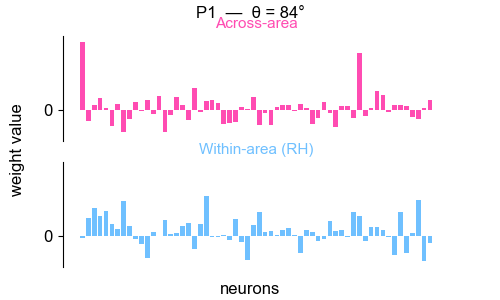

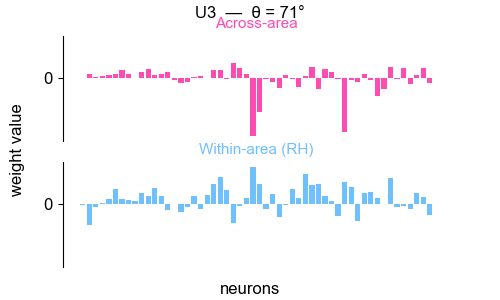

In [9]:
from tools.fig5_angles import top_pattern_signed, prinangle
import joblib

def plot_example(session_id, hemisphere='RH'):
    mp = joblib.load(os.path.join(RESULTS_DIR, session_id + WINDOW_SUFFIX + '.joblib'))['model_params']
    W = mp['W_2'] if hemisphere == 'RH' else mp['W_1']
    L = mp['L_2'] if hemisphere == 'RH' else mp['L_1']
    w = top_pattern_signed(W)
    l = top_pattern_signed(L)
    theta = prinangle(w, l)[0]
    n = len(w); x = np.arange(n)
    ymin = min(w.min(), l.min()) - 0.05
    ymax = max(w.max(), l.max()) + 0.05

    fig, ax = plt.subplots(2, 1, sharex=True, sharey=True, figsize=(5, 3))
    ax[0].bar(x, w, color=np.array([255,76,178])/255)      # across = pink
    ax[1].bar(x, l, color=np.array([111,192,255])/255)     # within = light blue
    ax[0].set_title('Across-area', color=np.array([255,76,178])/255, fontsize=11)
    ax[1].set_title('Within-area ({})'.format(hemisphere), color=np.array([111,192,255])/255, fontsize=11)
    for a in ax:
        a.set_xticks([]); a.set_yticks([0]); a.set_ylim([ymin, ymax])
        a.spines['bottom'].set_visible(False)
    fig.suptitle('{}  —  θ = {:.0f}°'.format(session_id, theta))
    fig.supylabel('weight value'); fig.supxlabel('neurons')
    if SAVE_FIG:
        fig.savefig(os.path.join(FIG_DIR, 'fig5b_weights_{}.pdf'.format(session_id)))
        fig.savefig(os.path.join(FIG_DIR, 'fig5b_weights_{}.png'.format(session_id)), dpi=200)
    plt.show()

plot_example('P1', 'RH')     # bilateral example
plot_example('U3', 'RH')     # unilateral example
